# How Machines Learn & How They Handle Uncertainty
### Topic 7: Calculus Basics  |  Topic 8: Probability & Statistics in ML

Run the cells **top to bottom** with **Shift + Enter**. Every cell prints a result or draws a picture.

| Part | What you will see |
|---|---|
| **Part 1 - Calculus** | derivative, partial derivative, gradient, Jacobian, Hessian, optimization, gradient descent, learning rate, local minima, mini-batch |
| **Part 2 - Probability & Statistics** | probability, conditional probability, Bayes, distributions, expected value, variance, LLN, CLT, hypothesis tests, confidence intervals, correlation, sampling bias, ECDF, chi-squared, KS test |

Cells marked **TRY IT** are for you to change and re-run.

In [1]:
# Setup - run once
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize

plt.rcParams.update({"figure.figsize": (7, 3.8), "axes.grid": True, "grid.alpha": 0.3})
TEAL, NAVY, CORAL, BLUE = "#39C2D7", "#263852", "#D35D47", "#008ACF"
rng = np.random.default_rng(42)          # fixed seed = same results every time
print("Ready!")

Ready!


---
# PART 1 - Calculus: how a model learns

**Our running example.** We predict a house price from its size: `price = w * size`.
One house: size = 2, real price = 6. The perfect weight is **w = 3** - but the model does not know it.

The **loss** (how wrong the model is) is the squared error: **L(w) = (6 - 2w)^2**.
**Training = finding the w at the bottom of this curve.**

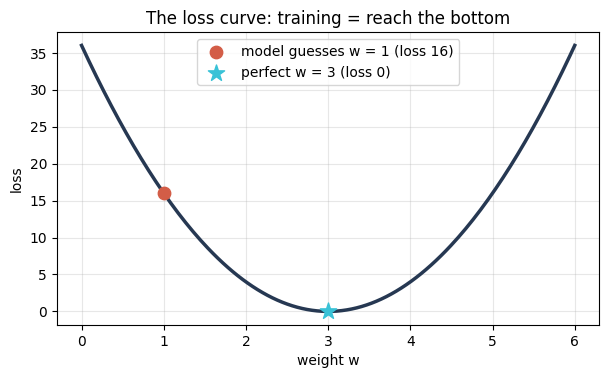

In [2]:
def loss(w):
    return (6 - 2*w)**2

w = np.linspace(0, 6, 200)
plt.plot(w, loss(w), color=NAVY, lw=2.5)
plt.scatter([1], [loss(1)], color=CORAL, s=80, zorder=5, label="model guesses w = 1 (loss 16)")
plt.scatter([3], [loss(3)], color=TEAL, s=150, marker="*", zorder=5, label="perfect w = 3 (loss 0)")
plt.xlabel("weight w"); plt.ylabel("loss"); plt.title("The loss curve: training = reach the bottom")
plt.legend(); plt.show()

## 1. Derivative = the slope at a point
The derivative tells us **how much the output changes when we nudge the input a tiny bit**.
We can measure it directly: *(change in output) / (change in input)* with a very small nudge `h`.

In [3]:
def derivative(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2*h)      # slope over a tiny step

f = lambda x: x**2
for h in [1, 0.1, 0.01, 0.0001]:
    print(f"nudge h = {h:<7} -> slope = {(f(3+h) - f(3)) / h:.4f}")
print("\nexact derivative of x^2 is 2x -> at x = 3:", 2*3)

nudge h = 1       -> slope = 7.0000
nudge h = 0.1     -> slope = 6.1000
nudge h = 0.01    -> slope = 6.0100
nudge h = 0.0001  -> slope = 6.0001

exact derivative of x^2 is 2x -> at x = 3: 6


**Rules you need:** power rule `x^n -> n*x^(n-1)` (so `x^2 -> 2x`), constants -> 0, sums -> differentiate each part.

### What the SIGN of the derivative tells us

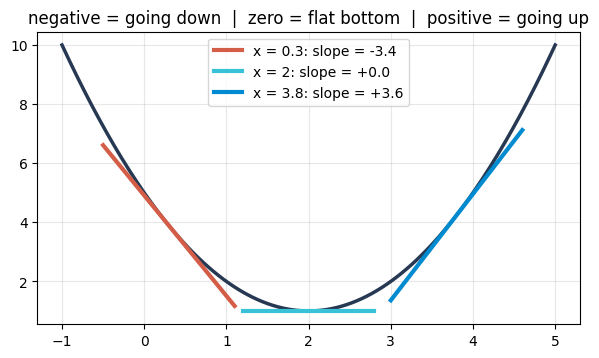

In [4]:
f = lambda x: (x - 2)**2 + 1
x = np.linspace(-1, 5, 200)
plt.plot(x, f(x), color=NAVY, lw=2.5)
for x0, col in [(0.3, CORAL), (2, TEAL), (3.8, BLUE)]:
    s = derivative(f, x0)
    xs = np.linspace(x0 - 0.8, x0 + 0.8, 10)
    plt.plot(xs, f(x0) + s*(xs - x0), color=col, lw=3, label=f"x = {x0}: slope = {s:+.1f}")
plt.title("negative = going down  |  zero = flat bottom  |  positive = going up")
plt.legend(); plt.show()

In [5]:
# Back to our house: which way should w move?
d = derivative(loss, 1)
print("slope of the loss at w = 1:", round(d, 2))
print("-> negative slope, so INCREASING w lowers the loss (move right, toward 3)")

slope of the loss at w = 1: -16.0
-> negative slope, so INCREASING w lowers the loss (move right, toward 3)


## 2. Partial derivative = change ONE input, freeze the others
`f(x, y) = x^2 + 3xy + y^2`
- df/dx = 2x + 3y  (y treated as a number)
- df/dy = 3x + 2y  (x treated as a number)

In [6]:
def f2(x, y):
    return x**2 + 3*x*y + y**2

x0, y0, h = 1, 2, 1e-6
dfdx = (f2(x0 + h, y0) - f2(x0 - h, y0)) / (2*h)   # nudge ONLY x
dfdy = (f2(x0, y0 + h) - f2(x0, y0 - h)) / (2*h)   # nudge ONLY y
print(f"df/dx at (1,2) = {dfdx:.2f}   (formula 2x + 3y = {2*1 + 3*2})")
print(f"df/dy at (1,2) = {dfdy:.2f}   (formula 3x + 2y = {3*1 + 2*2})")

df/dx at (1,2) = 8.00   (formula 2x + 3y = 8)
df/dy at (1,2) = 7.00   (formula 3x + 2y = 7)


## 3. Gradient = all partial derivatives in one vector
The gradient points **uphill** (steepest increase). **Minus the gradient points downhill** - that is where training goes.

In [7]:
def gradient(f, point, h=1e-6):
    point = np.array(point, dtype=float)
    g = np.zeros_like(point)
    for i in range(len(point)):          # one partial derivative per input
        step = np.zeros_like(point); step[i] = h
        g[i] = (f(*(point + step)) - f(*(point - step))) / (2*h)
    return g

print("gradient of x^2 + 3xy + y^2 at (1, 2):", gradient(f2, [1, 2]).round(2))

bowl = lambda x, y: x**2 + y**2
g = gradient(bowl, [2, 1])
print("gradient of x^2 + y^2 at (2, 1):     ", g.round(2), " -> uphill")
print("minus gradient:                       ", (-g).round(2), " -> downhill")

gradient of x^2 + 3xy + y^2 at (1, 2): [8. 7.]
gradient of x^2 + y^2 at (2, 1):      [4. 2.]  -> uphill
minus gradient:                        [-4. -2.]  -> downhill


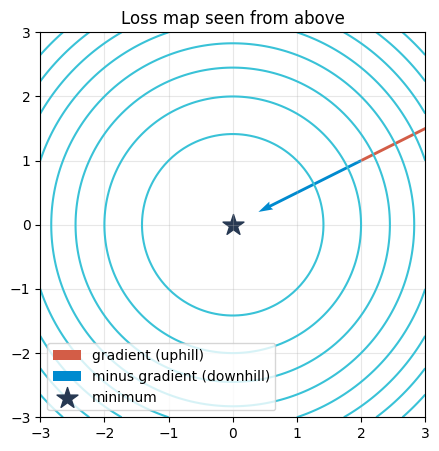

In [8]:
X, Y = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
plt.figure(figsize=(5, 5))
plt.contour(X, Y, X**2 + Y**2, levels=10, colors=TEAL)
plt.quiver(2, 1,  g[0],  g[1], color=CORAL, scale=15, label="gradient (uphill)")
plt.quiver(2, 1, -g[0], -g[1], color=BLUE,  scale=15, label="minus gradient (downhill)")
plt.scatter(0, 0, marker="*", s=250, color=NAVY, label="minimum")
plt.gca().set_aspect("equal"); plt.legend(loc="lower left"); plt.title("Loss map seen from above"); plt.show()

## 4. Jacobian = the gradient for functions with SEVERAL outputs
`f(x, y) = [ x*y , x + y ]` has 2 outputs -> the Jacobian is a 2 x 2 matrix: **rows = outputs, columns = inputs**.
In neural networks, every layer has a Jacobian; backpropagation multiplies them.

In [9]:
def vec_f(x, y):
    return np.array([x*y, x + y])

def jacobian(f, point, h=1e-6):
    point = np.array(point, dtype=float)
    cols = []
    for i in range(len(point)):
        step = np.zeros_like(point); step[i] = h
        cols.append((f(*(point + step)) - f(*(point - step))) / (2*h))
    return np.column_stack(cols)

print("Jacobian at (2, 3):\n", jacobian(vec_f, [2, 3]).round(2))
print("formula [[y, x], [1, 1]] =", [[3, 2], [1, 1]])

Jacobian at (2, 3):
 [[3. 2.]
 [1. 1.]]
formula [[y, x], [1, 1]] = [[3, 2], [1, 1]]


## 5. Hessian = curvature: bowl, dome or saddle?
The Hessian is the matrix of **second** derivatives. It is always **symmetric**.
Check its **eigenvalues**: all positive = bowl (**minimum**), all negative = dome (**maximum**), mixed = **saddle**.

In [10]:
def classify(H):
    ev = np.linalg.eigvalsh(H)
    if np.all(ev > 0):  kind = "all positive -> BOWL -> minimum (convex)"
    elif np.all(ev < 0): kind = "all negative -> DOME -> maximum"
    else:                kind = "mixed signs -> SADDLE (flat but not a minimum!)"
    return ev, kind

cases = {"x^2 + y^2":        np.array([[2, 0], [0, 2]]),
         "-x^2 - y^2":       np.array([[-2, 0], [0, -2]]),
         "x^2 + 3xy + y^2":  np.array([[2, 3], [3, 2]])}
for name, H in cases.items():
    ev, kind = classify(H)
    print(f"{name:<17} eigenvalues {ev} -> {kind}")

x^2 + y^2         eigenvalues [2. 2.] -> all positive -> BOWL -> minimum (convex)
-x^2 - y^2        eigenvalues [-2. -2.] -> all negative -> DOME -> maximum
x^2 + 3xy + y^2   eigenvalues [-1.  5.] -> mixed signs -> SADDLE (flat but not a minimum!)


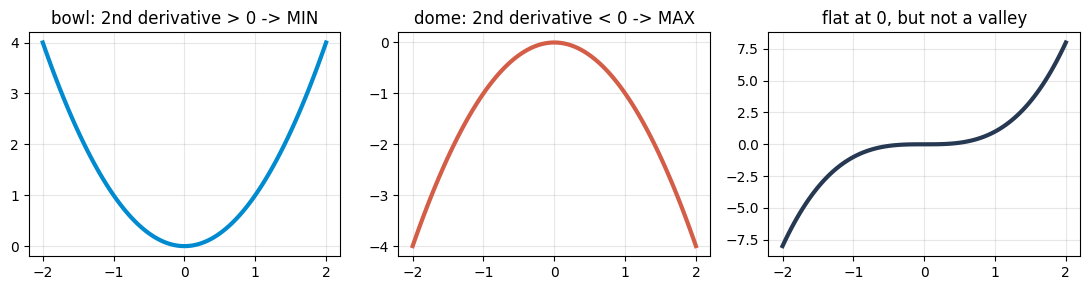

In [11]:
x = np.linspace(-2, 2, 100)
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].plot(x, x**2, color=BLUE, lw=3);  ax[0].set_title("bowl: 2nd derivative > 0 -> MIN")
ax[1].plot(x, -x**2, color=CORAL, lw=3); ax[1].set_title("dome: 2nd derivative < 0 -> MAX")
ax[2].plot(x, x**3, color=NAVY, lw=3);  ax[2].set_title("flat at 0, but not a valley")
plt.tight_layout(); plt.show()

## 6. Optimization = find the lowest point
**Unconstrained:** (1) set the derivative to 0, (2) check the second derivative.
Example: `f(x) = x^2 - 4x + 5`  ->  f'(x) = 2x - 4 = 0  ->  x = 2;  f''(x) = 2 > 0  ->  minimum.

In [12]:
f = lambda x: x**2 - 4*x + 5
res = optimize.minimize_scalar(f)
print(f"by hand: x = 2, f(2) = {f(2)}")
print(f"scipy:   x = {res.x:.4f}, f(x) = {res.fun:.4f}")

by hand: x = 2, f(2) = 1
scipy:   x = 2.0000, f(x) = 1.0000


**Constrained:** minimize `x^2 + y^2` **subject to** `x + y = 2` (Lagrange multipliers give x = y = 1).

In [13]:
obj = lambda v: v[0]**2 + v[1]**2
rule = {"type": "eq", "fun": lambda v: v[0] + v[1] - 2}      # the constraint x + y = 2
res = optimize.minimize(obj, x0=[0, 0], constraints=[rule])
print("best point:", res.x.round(4), "  value:", round(res.fun, 4))

best point: [1. 1.]   value: 2.0


**Why ML does not just solve 'gradient = 0':** a neural network has millions of weights and no formula to solve. So we **walk downhill step by step** -> gradient descent.

## 7. Gradient descent
### `w_new = w_old - learning_rate * gradient`
Back to the house: `L(w) = (6 - 2w)^2`, start at `w = 1`, learning rate `0.05`.

In [14]:
def dloss(w):
    return -4 * (6 - 2*w)          # derivative of (6 - 2w)^2 (chain rule)

w, lr = 1.0, 0.05
history = []
for step in range(12):
    history.append({"step": step, "w": round(w, 3), "loss": round(loss(w), 3), "gradient": round(dloss(w), 3)})
    w = w - lr * dloss(w)                          # the update rule
pd.DataFrame(history)

,step,w,loss,gradient
0,0,1.000,16.000,-16.000
1,1,1.800,5.760,-9.600
2,2,2.280,2.074,-5.760
3,3,2.568,0.746,-3.456
4,4,2.741,0.269,-2.074
5,5,2.844,0.097,-1.244
6,6,2.907,0.035,-0.746
7,7,2.944,0.013,-0.448
8,8,2.966,0.005,-0.269
9,9,2.980,0.002,-0.161


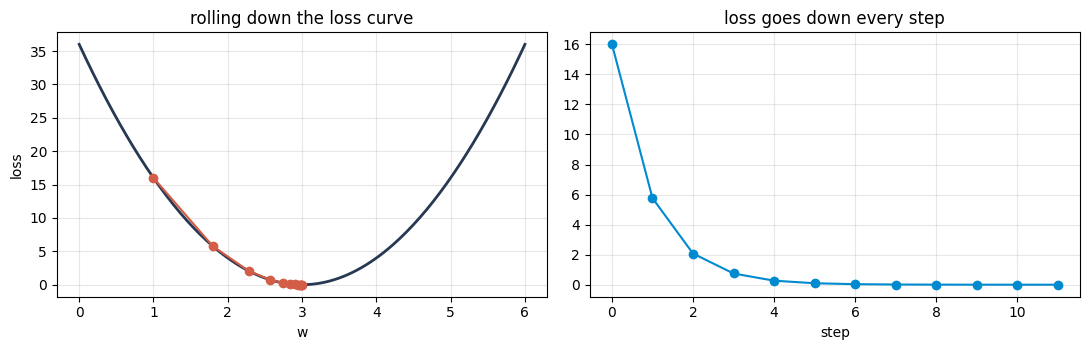

final w = 2.996  (the perfect answer is 3)


In [15]:
ws = [h["w"] for h in history]
wline = np.linspace(0, 6, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(wline, loss(wline), color=NAVY, lw=2)
ax[0].plot(ws, [loss(v) for v in ws], "o-", color=CORAL); ax[0].set_title("rolling down the loss curve")
ax[0].set_xlabel("w"); ax[0].set_ylabel("loss")
ax[1].plot([loss(v) for v in ws], "o-", color=BLUE); ax[1].set_title("loss goes down every step")
ax[1].set_xlabel("step"); plt.tight_layout(); plt.show()
print("final w =", round(w, 3), " (the perfect answer is 3)")

**Notice:** the steps get smaller on their own, because the slope gets flatter near the bottom.

### Activity check: "Be the algorithm" (f(x) = x^2, start x = 3, lr = 0.25)

In [16]:
x, lr = 3.0, 0.25
for step in range(1, 5):
    grad = 2*x
    x_new = x - lr*grad
    print(f"step {step}: x = {x:<6} gradient = {grad:<6} x_new = {x_new}")
    x = x_new
print("-> x halves every step and heads to 0, the minimum")

step 1: x = 3.0    gradient = 6.0    x_new = 1.5
step 2: x = 1.5    gradient = 3.0    x_new = 0.75
step 3: x = 0.75   gradient = 1.5    x_new = 0.375
step 4: x = 0.375  gradient = 0.75   x_new = 0.1875
-> x halves every step and heads to 0, the minimum


## 8. The learning rate: too small, just right, too big
For `f(x) = x^2`, each step multiplies x by `(1 - 2*lr)`.

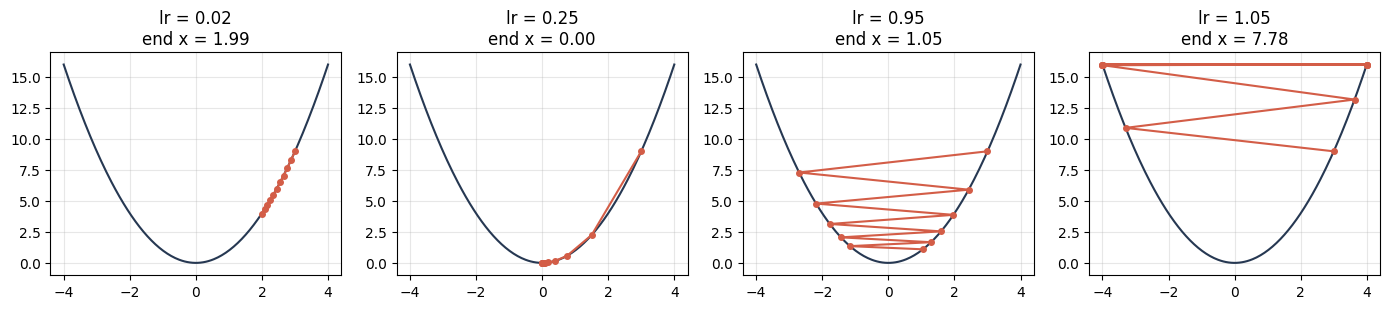

In [17]:
def run_gd(lr, x=3.0, steps=10):
    path = [x]
    for _ in range(steps):
        x = x - lr * 2*x
        path.append(x)
    return np.array(path)

rates = [0.02, 0.25, 0.95, 1.05]
fig, ax = plt.subplots(1, 4, figsize=(14, 3.2))
xx = np.linspace(-4, 4, 200)
for a, lr in zip(ax, rates):
    p = run_gd(lr); pc = np.clip(p, -4, 4)
    a.plot(xx, xx**2, color=NAVY); a.plot(pc, pc**2, "o-", color=CORAL, ms=4)
    a.set_title(f"lr = {lr}\nend x = {p[-1]:.2f}"); a.set_ylim(-1, 17)
plt.tight_layout(); plt.show()

**TRY IT:** change the learning rate and predict what happens *before* you run the cell.

In [18]:
lr = 0.1          # <- try 0.001, 0.5, 1.0, 1.5
print(run_gd(lr, steps=8).round(3))

[3.    2.4   1.92  1.536 1.229 0.983 0.786 0.629 0.503]


## 9. The main drawback: local minima
Gradient descent only feels the slope **where it stands**. Where it starts decides where it ends.

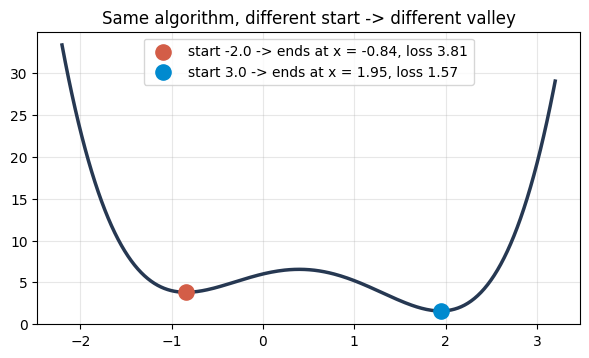

In [19]:
f = lambda x: x**4 - 2*x**3 - 2.4*x**2 + 2.6*x + 6
df = lambda x: 4*x**3 - 6*x**2 - 4.8*x + 2.6

xx = np.linspace(-2.2, 3.2, 300)
plt.plot(xx, f(xx), color=NAVY, lw=2.5)
for start, col in [(-2.0, CORAL), (3.0, BLUE)]:
    x = start
    for _ in range(200):
        x -= 0.01 * df(x)
    plt.scatter(x, f(x), s=120, color=col, zorder=5, label=f"start {start} -> ends at x = {x:.2f}, loss {f(x):.2f}")
plt.title("Same algorithm, different start -> different valley"); plt.legend(); plt.show()

## 10. Batch vs SGD vs Mini-batch
Real data: many examples. **How many examples do we use per update?**
- **Batch**: all of them - smooth, slow
- **SGD**: 1 - fast, noisy
- **Mini-batch**: a small group (e.g. 32) - the standard in deep learning

We learn `y = 3x + 2` from 1000 noisy points.

In [20]:
n = 1000
X = rng.uniform(-2, 2, n)
y = 3*X + 2 + rng.normal(0, 0.5, n)          # true slope 3, intercept 2

def mse(w, b): return np.mean((y - (w*X + b))**2)

def train(batch_size, lr=0.05, epochs=5):
    w, b, losses = 0.0, 0.0, []
    for epoch in range(epochs):
        idx = rng.permutation(n)             # shuffle every epoch
        for start in range(0, n, batch_size):
            bi = idx[start:start + batch_size]
            err = y[bi] - (w*X[bi] + b)
            w -= lr * (-2*np.mean(err*X[bi]))   # gradient for w
            b -= lr * (-2*np.mean(err))         # gradient for b
            losses.append(mse(w, b))
    return w, b, losses

for name, bs in [("Batch (1000)", 1000), ("Mini-batch (32)", 32), ("SGD (1)", 1)]:
    w_, b_, L = train(bs)
    print(f"{name:<16} updates = {len(L):<5} w = {w_:.3f}  b = {b_:.3f}  final loss = {L[-1]:.3f}")

Batch (1000)     updates = 5     w = 1.561  b = 0.793  final loss = 4.496
Mini-batch (32)  updates = 160   w = 3.039  b = 1.980  final loss = 0.257
SGD (1)          updates = 5000  w = 2.966  b = 1.878  final loss = 0.268


**Read the result:** all three saw the data the same number of times (5 epochs).
Full batch made only **5 updates**, so it is still far from w = 3, b = 2.
Mini-batch made **160 updates** and found the answer. SGD made 5000 noisy updates.
That is why deep learning uses **mini-batch**: many updates, but each one still fairly reliable.

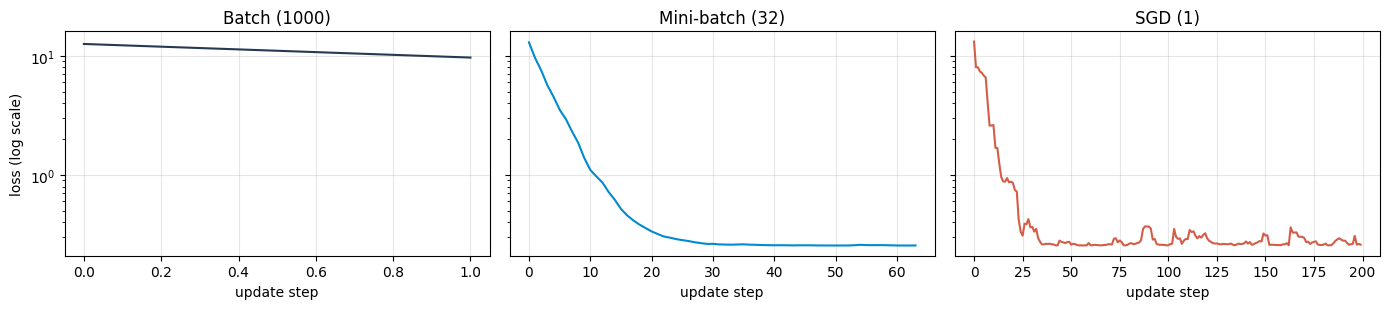

1 epoch = one pass over all data.  1000 examples, batch 32 -> about 32 updates per epoch.


In [21]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.2), sharey=True)
for a, (name, bs, col) in zip(ax, [("Batch (1000)", 1000, NAVY), ("Mini-batch (32)", 32, BLUE), ("SGD (1)", 1, CORAL)]):
    _, _, L = train(bs, epochs=2)
    a.plot(L[:200], color=col); a.set_title(name); a.set_xlabel("update step"); a.set_yscale("log")
ax[0].set_ylabel("loss (log scale)"); plt.tight_layout(); plt.show()
print("1 epoch = one pass over all data.  1000 examples, batch 32 -> about 32 updates per epoch.")

**Part 1 summary:** derivative = slope · gradient = uphill arrow · Hessian = bowl or dome ·
gradient descent `w = w - lr * gradient` · watch the learning rate and local minima · use mini-batch.
**Training = rolling downhill to the lowest error.**

---
# PART 2 - Probability & Statistics: handling uncertainty
- **Probability** looks **forward**: known model -> predict data
- **Statistics** looks **backward**: observed data -> infer the model

In [22]:
# Probability (forward): a fair coin -> what do we expect?
flips = rng.integers(0, 2, 100)
print("fair coin, 100 flips ->", flips.sum(), "heads (expected about 50)")

# Statistics (backward): we saw 70 heads - is the coin fair?
p = stats.binomtest(70, 100, 0.5).pvalue
print("observed 70 heads -> p-value =", round(p, 5), "-> very unlikely for a fair coin")

fair coin, 100 flips -> 43 heads (expected about 50)
observed 70 heads -> p-value = 8e-05 -> very unlikely for a fair coin


## 11. Sample space, events, probability
Sample space of a die = {1,...,6}. Event "even" = {2, 4, 6}. P(even) = 3/6 = 0.5.
Simulation check: roll many times and count.

In [23]:
rolls = rng.integers(1, 7, 100_000)
print("P(even)  theory 0.500   simulation", round(np.mean(rolls % 2 == 0), 3))
print("P(six)   theory 0.167   simulation", round(np.mean(rolls == 6), 3))
print("P(not six) = 1 - 1/6 =", round(1 - 1/6, 3))
two = rng.integers(0, 2, (100_000, 2))
print("P(two heads) theory 0.25 simulation", round(np.mean(two.sum(axis=1) == 2), 3))

P(even)  theory 0.500   simulation 0.499
P(six)   theory 0.167   simulation 0.167
P(not six) = 1 - 1/6 = 0.833
P(two heads) theory 0.25 simulation 0.249


## 12. Conditional probability  P(A | B) = P(A and B) / P(B)
"Given B" = shrink your world to the cases where B is true.

In [24]:
emails = pd.DataFrame({
    "spam": ["spam"]*30 + ["spam"]*10 + ["not spam"]*20 + ["not spam"]*40,
    "free": ["yes"]*30  + ["no"]*10   + ["yes"]*20       + ["no"]*40 })
table = pd.crosstab(emails["free"], emails["spam"], margins=True)
table

spam,not spam,spam,All
free,,,
no,40,10,50
yes,20,30,50
All,60,40,100


In [25]:
p_spam = (emails.spam == "spam").mean()
free = emails[emails.free == "yes"]                 # shrink the world to 'free' emails
p_spam_given_free = (free.spam == "spam").mean()
spam = emails[emails.spam == "spam"]
p_free_given_spam = (spam.free == "yes").mean()

print("P(spam)          =", p_spam)
print("P(spam | free)   =", p_spam_given_free, " <- evidence raised our belief")
print("P(free | spam)   =", p_free_given_spam, " <- a DIFFERENT question!")

P(spam)          = 0.4
P(spam | free)   = 0.6  <- evidence raised our belief
P(free | spam)   = 0.75  <- a DIFFERENT question!


### Independence: P(A and B) = P(A) * P(B)

In [26]:
p_free = (emails.free == "yes").mean()
p_both = ((emails.spam == "spam") & (emails.free == "yes")).mean()
print("P(spam) * P(free) =", round(p_spam*p_free, 2), "  P(spam and free) =", p_both)
print("-> not equal, so 'spam' and 'free' are NOT independent (the word carries information)")

P(spam) * P(free) = 0.2   P(spam and free) = 0.3
-> not equal, so 'spam' and 'free' are NOT independent (the word carries information)


## 13. Bayes' theorem  P(A|B) = P(B|A) P(A) / P(B)
A disease affects 1%. The test catches 99% of sick people; 5% false alarms. You test positive. Chance you are sick?

In [27]:
prior, sens, false_pos = 0.01, 0.99, 0.05
posterior = sens*prior / (sens*prior + false_pos*(1 - prior))
print("Bayes formula:", round(posterior, 3))

# Check by simulating 1,000,000 people
N = 1_000_000
sick = rng.random(N) < prior
positive = np.where(sick, rng.random(N) < sens, rng.random(N) < false_pos)
print("simulation:   ", round(sick[positive].mean(), 3))
print(f"positives: {positive.sum():,}   truly sick among them: {sick[positive].sum():,}")

Bayes formula: 0.167
simulation:    0.165
positives: 59,498   truly sick among them: 9,841


**Only ~17%.** The disease is rare, so most positives are false alarms (**base-rate neglect**).
**TRY IT:** set `prior = 0.2` (a common disease) and see how the answer changes.

## 14. Random variables and distributions
**Discrete** (we count): Bernoulli, Binomial, Multinomial, Poisson, Geometric
**Continuous** (we measure): Gaussian, Uniform, Exponential

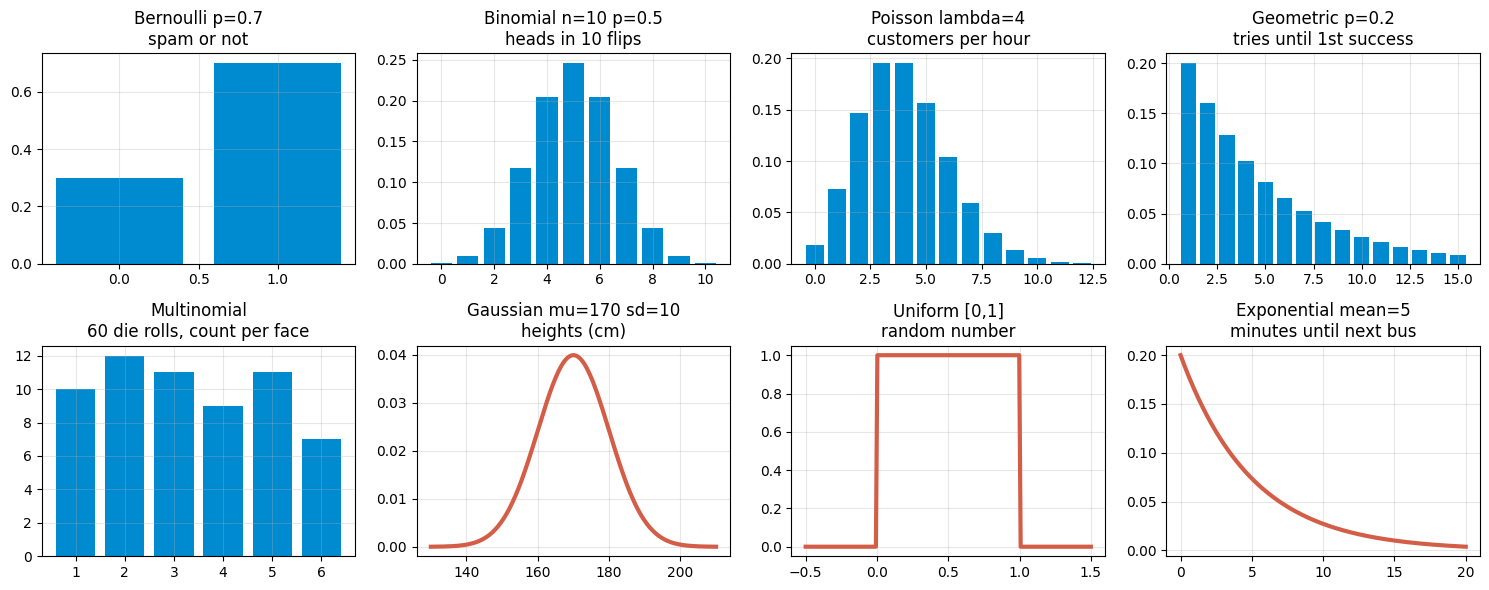

In [28]:
fig, ax = plt.subplots(2, 4, figsize=(15, 6))
ax = ax.ravel()
ax[0].bar([0, 1], stats.bernoulli.pmf([0, 1], 0.7), color=BLUE); ax[0].set_title("Bernoulli p=0.7\nspam or not")
k = np.arange(11); ax[1].bar(k, stats.binom.pmf(k, 10, 0.5), color=BLUE); ax[1].set_title("Binomial n=10 p=0.5\nheads in 10 flips")
k = np.arange(13); ax[2].bar(k, stats.poisson.pmf(k, 4), color=BLUE); ax[2].set_title("Poisson lambda=4\ncustomers per hour")
k = np.arange(1, 16); ax[3].bar(k, stats.geom.pmf(k, 0.2), color=BLUE); ax[3].set_title("Geometric p=0.2\ntries until 1st success")
counts = rng.multinomial(60, [1/6]*6); ax[4].bar(range(1, 7), counts, color=BLUE); ax[4].set_title("Multinomial\n60 die rolls, count per face")
x = np.linspace(130, 210, 200); ax[5].plot(x, stats.norm.pdf(x, 170, 10), color=CORAL, lw=3); ax[5].set_title("Gaussian mu=170 sd=10\nheights (cm)")
x = np.linspace(-0.5, 1.5, 200); ax[6].plot(x, stats.uniform.pdf(x), color=CORAL, lw=3); ax[6].set_title("Uniform [0,1]\nrandom number")
x = np.linspace(0, 20, 200); ax[7].plot(x, stats.expon.pdf(x, scale=5), color=CORAL, lw=3); ax[7].set_title("Exponential mean=5\nminutes until next bus")
plt.tight_layout(); plt.show()

In [29]:
print("P(exactly 5 heads in 10 flips)      =", round(stats.binom.pmf(5, 10, 0.5), 3))
print("P(exactly 3 customers, avg 4)       =", round(stats.poisson.pmf(3, 4), 3))
print("Geometric p=0.2: expected tries     =", 1/0.2)
print("Height 160-180 (1 sd)  =", round(stats.norm.cdf(180,170,10) - stats.norm.cdf(160,170,10), 3), " (68% rule)")
print("Height 150-190 (2 sd)  =", round(stats.norm.cdf(190,170,10) - stats.norm.cdf(150,170,10), 3), " (95% rule)")
print("P(exact height 170.000) for a continuous variable = 0 -> probability = AREA under the curve")

P(exactly 5 heads in 10 flips)      = 0.246
P(exactly 3 customers, avg 4)       = 0.195
Geometric p=0.2: expected tries     = 5.0
Height 160-180 (1 sd)  = 0.683  (68% rule)
Height 150-190 (2 sd)  = 0.954  (95% rule)
P(exact height 170.000) for a continuous variable = 0 -> probability = AREA under the curve


## 15. Expected value, variance, covariance
- **Expected value** = long-run average (a loss is an *expected* error)
- **Variance / std** = how spread out
- **Covariance / correlation** = do two variables move together? (PCA uses the covariance matrix)

In [30]:
die = np.arange(1, 7)
print("E[fair die] = ", die.mean(), "  simulation of 100k rolls:", round(rolls.mean(), 3))

data = np.array([2, 4, 6])
print("\ndata", data, "-> mean", data.mean(), " variance", round(data.var(), 2), " std", round(data.std(), 2))

archer_A = rng.normal(0, 0.3, 20)     # consistent
archer_B = rng.normal(0, 1.5, 20)     # erratic
print("archer A: mean", round(archer_A.mean(), 2), " std", round(archer_A.std(), 2))
print("archer B: mean", round(archer_B.mean(), 2), " std", round(archer_B.std(), 2), " <- same centre, more spread")

E[fair die] =  3.5   simulation of 100k rolls: 3.507

data [2 4 6] -> mean 4.0  variance 2.67  std 1.63
archer A: mean 0.06  std 0.33
archer B: mean -0.27  std 1.63  <- same centre, more spread


cov(size, price)   = 877468 (positive)
corr(size, price)  = 0.91
corr(age, car)     = -0.92 (negative)


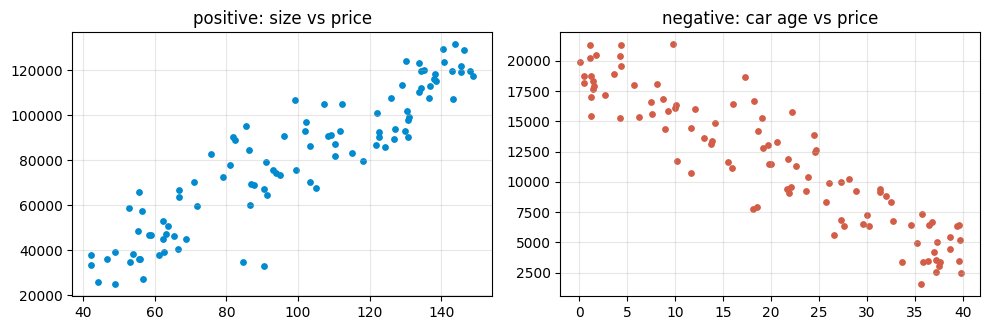

In [31]:
size  = rng.uniform(40, 150, 100)                       # m^2
price = 800*size + rng.normal(0, 12000, 100)            # rises with size
age   = rng.uniform(0, 40, 100)
car_price = 20000 - 400*age + rng.normal(0, 2000, 100) # falls with age

print("cov(size, price)   =", round(np.cov(size, price)[0, 1]), "(positive)")
print("corr(size, price)  =", round(np.corrcoef(size, price)[0, 1], 2))
print("corr(age, car)     =", round(np.corrcoef(age, car_price)[0, 1], 2), "(negative)")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].scatter(size, price, color=BLUE, s=15); ax[0].set_title("positive: size vs price")
ax[1].scatter(age, car_price, color=CORAL, s=15); ax[1].set_title("negative: car age vs price")
plt.tight_layout(); plt.show()

## 16. Law of Large Numbers: more data -> closer to the truth

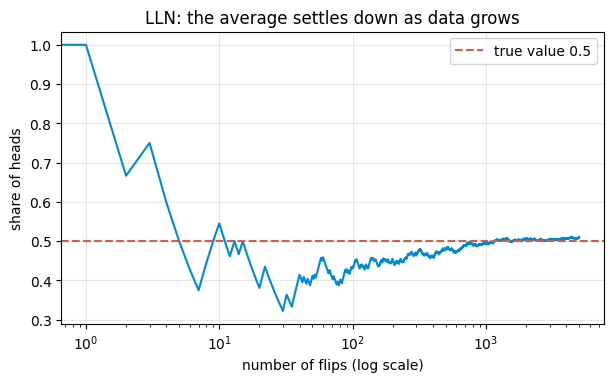

after   10 flips: 0.500
after  100 flips: 0.430
after 1000 flips: 0.494
after 5000 flips: 0.510


In [32]:
flips = rng.integers(0, 2, 5000)
running = np.cumsum(flips) / np.arange(1, 5001)
plt.plot(running, color=BLUE); plt.axhline(0.5, color=CORAL, ls="--", label="true value 0.5")
plt.xscale("log"); plt.xlabel("number of flips (log scale)"); plt.ylabel("share of heads")
plt.title("LLN: the average settles down as data grows"); plt.legend(); plt.show()
for k in [10, 100, 1000, 5000]:
    print(f"after {k:>4} flips: {running[k-1]:.3f}")

## 17. Central Limit Theorem: averages form a bell curve - even from skewed data

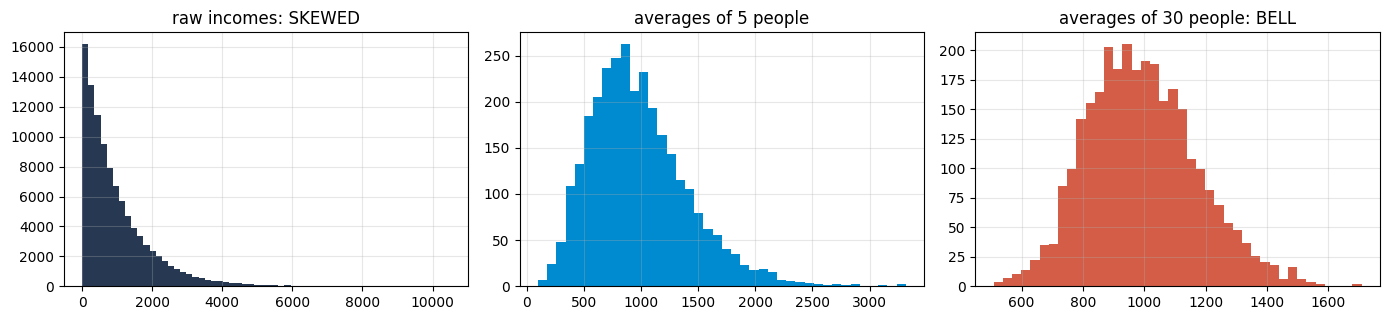

std of raw data: 995 | std of averages of 30: 179 | theory sigma/sqrt(n): 182


In [33]:
incomes = rng.exponential(1000, 100_000)                    # very skewed
means_5  = [rng.choice(incomes, 5).mean()  for _ in range(3000)]
means_30 = [rng.choice(incomes, 30).mean() for _ in range(3000)]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.3))
ax[0].hist(incomes, bins=60, color=NAVY); ax[0].set_title("raw incomes: SKEWED")
ax[1].hist(means_5, bins=40, color=BLUE); ax[1].set_title("averages of 5 people")
ax[2].hist(means_30, bins=40, color=CORAL); ax[2].set_title("averages of 30 people: BELL")
plt.tight_layout(); plt.show()
print("std of raw data:", round(incomes.std()), "| std of averages of 30:", round(np.std(means_30)),
      "| theory sigma/sqrt(n):", round(incomes.std()/np.sqrt(30)))

## 18. Descriptive statistics: centre and spread
Nine teachers earn about $1200. A CEO earning $20,000 joins the room.

In [34]:
salaries = pd.Series([900, 1000, 1000, 1100, 1200, 1200, 1300, 1400, 1500])
for label, s in [("before CEO", salaries), ("after CEO ", pd.concat([salaries, pd.Series([20000])]))]:
    print(f"{label}: mean {s.mean():7.0f} | median {s.median():6.0f} | mode {s.mode()[0]:5} | "
          f"range {s.max()-s.min():6} | std {s.std():7.0f}")
print("\n-> the mean jumps, the median stays: use the MEDIAN when there are outliers (Topic 5!)")

before CEO: mean    1178 | median   1200 | mode  1000 | range    600 | std     199
after CEO : mean    3060 | median   1200 | mode  1000 | range  19100 | std    5955

-> the mean jumps, the median stays: use the MEDIAN when there are outliers (Topic 5!)


## 19. Hypothesis testing and p-values (the courtroom)
- H0 (innocent): the coin is fair  |  H1 (guilty): it is biased
- p-value = how likely results this extreme are **IF H0 is true**. p < 0.05 -> reject H0.

In [35]:
for heads in [55, 60, 65, 70]:
    p = stats.binomtest(heads, 100, 0.5).pvalue
    verdict = "reject H0 (biased)" if p < 0.05 else "cannot reject H0"
    print(f"{heads} heads of 100 -> p = {p:.4f} -> {verdict}")

55 heads of 100 -> p = 0.3682 -> cannot reject H0
60 heads of 100 -> p = 0.0569 -> cannot reject H0
65 heads of 100 -> p = 0.0035 -> reject H0 (biased)
70 heads of 100 -> p = 0.0001 -> reject H0 (biased)


**ML example:** is model B really better than model A, or just lucky? Compare their accuracy over 10 different data splits.

In [36]:
acc_A = rng.normal(0.85, 0.01, 10)
acc_B = rng.normal(0.87, 0.01, 10)
t, p = stats.ttest_ind(acc_B, acc_A)
print("mean A =", round(acc_A.mean(), 3), " mean B =", round(acc_B.mean(), 3), " p =", round(p, 5))
print("-> B is significantly better" if p < 0.05 else "-> difference could be luck")

mean A = 0.845  mean B = 0.871  p = 7e-05
-> B is significantly better


**Remember:** p = 0.03 does NOT mean "3% chance H0 is true". It means "**if** H0 were true, data this extreme would appear 3% of the time".

## 20. Confidence intervals: mean +/- 1.96 * std / sqrt(n)

In [37]:
scores = rng.normal(50, 10, 100)
m, se = scores.mean(), scores.std(ddof=1) / np.sqrt(len(scores))
print(f"mean = {m:.2f}, standard error = {se:.2f}")
print(f"95% CI by formula:  [{m - 1.96*se:.2f}, {m + 1.96*se:.2f}]")
lo, hi = stats.t.interval(0.95, len(scores)-1, loc=m, scale=se)
print(f"95% CI with scipy:  [{lo:.2f}, {hi:.2f}]")

mean = 51.75, standard error = 0.89
95% CI by formula:  [50.00, 53.49]
95% CI with scipy:  [49.98, 53.51]


**The fishing net:** draw 100 samples, build 100 intervals. About 95 catch the true mean.

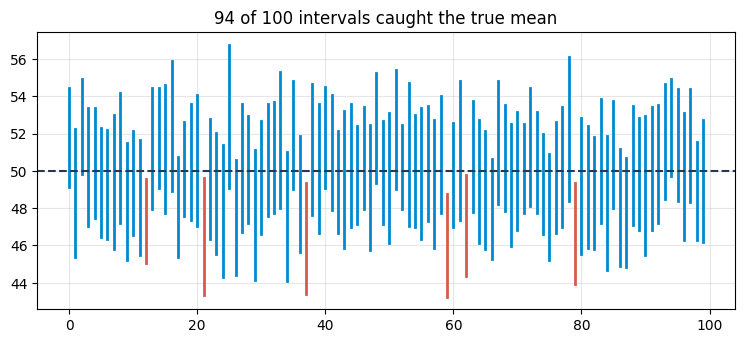

In [38]:
true_mean, hits = 50, 0
plt.figure(figsize=(9, 3.6))
for i in range(100):
    s = rng.normal(true_mean, 10, 40)
    m, se = s.mean(), s.std(ddof=1)/np.sqrt(40)
    lo, hi = m - 1.96*se, m + 1.96*se
    hit = lo <= true_mean <= hi; hits += hit
    plt.plot([i, i], [lo, hi], color=BLUE if hit else CORAL, lw=2)
plt.axhline(true_mean, color=NAVY, ls="--"); plt.title(f"{hits} of 100 intervals caught the true mean"); plt.show()

## 21. Correlation is NOT causation
Hot weather drives **both** ice-cream sales and drownings (a **confounder**).

corr(ice cream, drownings) = 0.86 -> strong!
same corr on hot days only = 0.32 -> almost gone: heat was the real cause


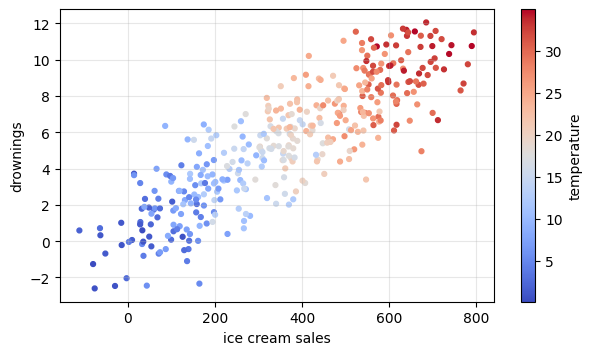

In [39]:
temp = rng.uniform(0, 35, 365)                           # daily temperature
ice_cream = 20*temp + rng.normal(0, 60, 365)
drownings = 0.3*temp + rng.normal(0, 1.5, 365)
print("corr(ice cream, drownings) =", round(np.corrcoef(ice_cream, drownings)[0, 1], 2), "-> strong!")

hot = temp > 25                                          # hold temperature (roughly) fixed
print("same corr on hot days only =", round(np.corrcoef(ice_cream[hot], drownings[hot])[0, 1], 2),
      "-> almost gone: heat was the real cause")
plt.scatter(ice_cream, drownings, c=temp, cmap="coolwarm", s=12); plt.colorbar(label="temperature")
plt.xlabel("ice cream sales"); plt.ylabel("drownings"); plt.show()

## 22. Population vs sample: beware of sampling bias

In [40]:
city = rng.normal(3, 1.5, 100_000).clip(0)               # weekly exercise hours, whole city
gym_goers = city[city > 5]                                 # survey done ONLY at the gym
random_sample = rng.choice(city, 500)
print("true city average:       ", round(city.mean(), 2), "h")
print("random sample of 500:    ", round(random_sample.mean(), 2), "h   <- representative")
print("survey at the gym only:  ", round(rng.choice(gym_goers, 500).mean(), 2), "h   <- BIASED")

true city average:        3.02 h
random sample of 500:     3.02 h   <- representative
survey at the gym only:   5.68 h   <- BIASED


---
# The practice exercises (AutoCode)
## 23. ECDF - fraction of data at or below each value

In [41]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x, y = ecdf([3, 1, 2, 2, 5])
for xi, yi in zip(x, y):
    print(f"ECDF({xi}) = {yi:.1f}")

ECDF(1) = 0.2
ECDF(2) = 0.4
ECDF(2) = 0.6
ECDF(3) = 0.8
ECDF(5) = 1.0


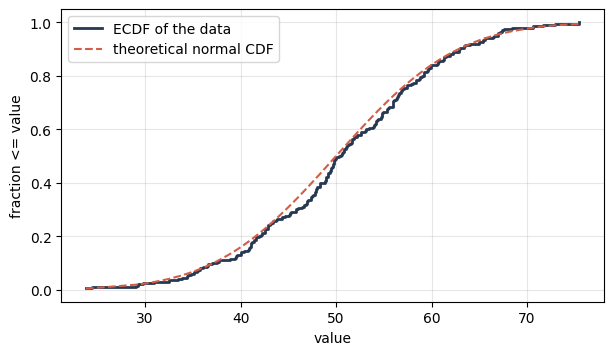

In [42]:
a = rng.normal(50, 10, 200)
xa, ya = ecdf(a)
plt.step(xa, ya, where="post", color=NAVY, lw=2, label="ECDF of the data")
plt.plot(xa, stats.norm.cdf(xa, 50, 10), color=CORAL, ls="--", label="theoretical normal CDF")
plt.xlabel("value"); plt.ylabel("fraction <= value"); plt.legend(); plt.show()

## 24. Chi-squared test - are two categorical variables related?
Compare **observed** counts with the counts **expected if they were independent**.

In [43]:
observed = np.array([[30, 20],     # free = yes : spam, not spam
                     [10, 40]])    # free = no  : spam, not spam
row, col, total = observed.sum(1, keepdims=True), observed.sum(0, keepdims=True), observed.sum()
expected = row @ col / total
print("expected if independent:\n", expected)
chi2_hand = ((observed - expected)**2 / expected).sum()
print("\nchi-squared by hand:", round(chi2_hand, 2))
chi2, p, dof, _ = stats.chi2_contingency(observed, correction=False)
print("scipy: chi2 =", round(chi2, 2), " p =", round(p, 6), " -> spam and 'free' ARE related")

expected if independent:
 [[20. 30.]
 [20. 30.]]

chi-squared by hand: 16.67
scipy: chi2 = 16.67  p = 4.5e-05  -> spam and 'free' ARE related


## 25. Two-sample Kolmogorov-Smirnov test - same distribution?
The KS statistic = the **largest vertical gap** between the two ECDFs. In ML: has new data drifted away from the training data?

same distribution  KS = 0.060  p = 0.6536  -> looks the same
drifted data       KS = 0.140  p = 0.0055  -> different!


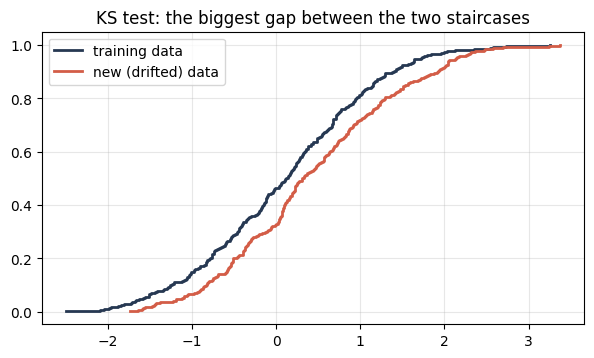

In [44]:
train_data = rng.normal(0, 1, 300)
new_same   = rng.normal(0, 1, 300)
new_drift  = rng.normal(0.5, 1, 300)
for name, s in [("same distribution", new_same), ("drifted data", new_drift)]:
    stat, p = stats.ks_2samp(train_data, s)
    print(f"{name:<18} KS = {stat:.3f}  p = {p:.4f}  -> {'different!' if p < 0.05 else 'looks the same'}")

for s, col, lab in [(train_data, NAVY, "training data"), (new_drift, CORAL, "new (drifted) data")]:
    xs, ys = ecdf(s); plt.step(xs, ys, where="post", color=col, lw=2, label=lab)
plt.title("KS test: the biggest gap between the two staircases"); plt.legend(); plt.show()

---
# Summary
| | Key idea |
|---|---|
| **Calculus** | derivative = slope, gradient = uphill arrow, **w = w - lr * gradient**, choose lr carefully, beware local minima, use mini-batch |
| **Probability** | forward from model to data; conditional probability and Bayes update beliefs; distributions describe randomness |
| **Statistics** | backward from data to model; LLN and CLT; p-values and confidence intervals; correlation is not causation; representative samples |

**Training = rolling downhill to the lowest error. ML = managing uncertainty with numbers.**